## 0 — Install (run once, then restart runtime)

In [1]:
!python -m pip install -U pip
!python -m pip install "scipy>=1.14.1"

In [2]:
!pip uninstall -y transformers setfit sentence-transformers huggingface-hub
!pip install "setfit==1.1.3" "transformers<5" "sentence-transformers<5"

Found existing installation: transformers 4.57.6
Uninstalling transformers-4.57.6:
  Successfully uninstalled transformers-4.57.6
Found existing installation: setfit 1.1.3
Uninstalling setfit-1.1.3:
  Successfully uninstalled setfit-1.1.3
Found existing installation: sentence-transformers 4.1.0
Uninstalling sentence-transformers-4.1.0:
  Successfully uninstalled sentence-transformers-4.1.0
Found existing installation: huggingface_hub 0.36.2
Uninstalling huggingface_hub-0.36.2:
  Successfully uninstalled huggingface_hub-0.36.2
  Using cached setfit-1.1.3-py3-none-any.whl.metadata (12 kB)
  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached sentence_transformers-4.1.0-py3-none-any.whl.metadata (13 kB)
  Using cached huggingface_hub-1.7.2-py3-none-any.whl.metadata (13 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
Using cached setfit-1.1.3-py3-none-any.whl (75 kB)
Using cached transformers-4.57.6-py3-none-any.whl (12.0 MB)
Using 

### Stability changes applied
- 5-fold CV kept unchanged
- lower source batch size with gradient accumulation
- mixed precision (`fp16`) enabled for source transformer training
- smaller embedding extraction batches to reduce OOM risk
- SetFit encoding batch size reduced and contrastive iterations lowered

Run each notebook in a fresh Colab runtime.

## 1 — Config & Drive

In [3]:
import torch
import numpy as np
import os

PRIMARY_CSV_PATH = "primary.csv"
TEXT_COL  = "text"
LABEL_COL = "category"

CFG = {
    "max_length"         : 128,
    "primary_num_labels" : 7,
    "n_folds"            : 5,
    "seed"               : 42,
    "output_dir"         : "output",
    "device"             : "cuda" if torch.cuda.is_available() else "cpu",
    "deberta_model"      : "microsoft/deberta-v3-base",
    "mpnet_model"        : "sentence-transformers/all-mpnet-base-v2",
    "setfit_model"       : "sentence-transformers/paraphrase-mpnet-base-v2",
    "lora_r"             : 16,
    "lora_alpha"         : 32,
    "lora_dropout"       : 0.1,
    "primary_epochs"     : 5,
    "primary_lr"         : 2e-4,
    "primary_batch_size" : 4,
    "grad_accum_steps"   : 4,
    "extract_batch_size" : 16,
    "use_fp16"           : True,
    "probe_epochs"       : 10,
    "probe_lr"           : 1e-3,
    "probe_batch_size"   : 32,
    "neural_epochs"      : 15,
    "neural_lr"          : 1e-3,
    "neural_batch_size"  : 32,
    "setfit_epochs"      : 1,
    "setfit_num_iters"   : 10,
    "ensemble_weights"   : [0.25, 0.45, 0.30],
}
os.makedirs(CFG["output_dir"], exist_ok=True)
torch.manual_seed(CFG["seed"]); np.random.seed(CFG["seed"])
print(f"✅ Device: {CFG['device']}")

✅ Device: cpu


## 2 — Imports

In [4]:
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType
from sentence_transformers import SentenceTransformer
from setfit import SetFitModel, Trainer
from datasets import load_dataset, Dataset as HFDataset
print("✅ Imports OK")

✅ Imports OK


## 3 — Shared Utilities

In [5]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.enc = tokenizer(texts, truncation=True, padding="max_length",
                             max_length=max_length, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.labels[i]
        return item

class LinearProbe(nn.Module):
    def __init__(self, in_dim, num_labels):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_labels)
    def forward(self, x): return self.fc(x)

def make_result(name, accs, f1s):
    return dict(
        dataset=name,
        accuracy_mean=round(float(np.mean(accs)), 4),
        accuracy_std =round(float(np.std(accs)),  4),
        f1_mean      =round(float(np.mean(f1s)),  4),
        f1_std       =round(float(np.std(f1s)),   4),
        per_fold_acc =[round(a,4) for a in accs],
        per_fold_f1  =[round(f,4) for f in f1s],
    )

def print_result(model_name, ds_name, r):
    folds = r.get("per_fold_acc", [])
    fold_str = "  ".join([f"F{i+1}:{v:.4f}" for i,v in enumerate(folds)])
    print(f"  ► [{model_name}] {ds_name}: "
          f"acc={r['accuracy_mean']:.4f}±{r['accuracy_std']:.4f}  "
          f"f1={r['f1_mean']:.4f}±{r['f1_std']:.4f}")
    print(f"    Per-fold acc: {fold_str}")

print("✅ Utilities ready")

✅ Utilities ready


## 4 — Load Primary Dataset

In [6]:
df = pd.read_csv(PRIMARY_CSV_PATH)
print(f"Loaded: {len(df)} rows | columns: {df.columns.tolist()}")
print(df[LABEL_COL].value_counts().sort_index())

primary_texts = df[TEXT_COL].astype(str).tolist()
le = LabelEncoder()
primary_labels = le.fit_transform(df[LABEL_COL].astype(str)).tolist()
CFG["primary_num_labels"] = len(le.classes_)
assert len(set(primary_labels)) == CFG["primary_num_labels"]
print(f"\n✅ {len(primary_texts)} samples, {len(set(primary_labels))} classes")

Loaded: 959 rows | columns: ['text', 'category']
category
Career Preparation             98
Extracurricular Activities    195
Facilities and Resources       88
Improvement Suggestions       202
Social Experience              86
Support Services               93
Teaching Quality              197
Name: count, dtype: int64

✅ 959 samples, 7 classes


## 5 — Load Target Datasets

In [7]:
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter

def load_edura():
    ds    = load_dataset("yhua219/EduRABSA_SA")
    split = "train" if "train" in ds else list(ds.keys())[0]
    data  = ds[split]
    
    # Print columns so we can verify
    print(f"EduRABSA columns: {data.column_names}")
    
    texts  = [str(t) for t in data["text"]]
    
    # Try "output" first, fall back to other common names
    if "output" in data.column_names:
        raw_lb = [str(l).strip() for l in data["output"]]
    elif "sentiment" in data.column_names:
        raw_lb = [str(l).strip() for l in data["sentiment"]]
    elif "label" in data.column_names:
        raw_lb = [str(l).strip() for l in data["label"]]
    else:
        # Use last column as fallback
        col = data.column_names[-1]
        print(f"  Using fallback column: {col}")
        raw_lb = [str(l).strip() for l in data[col]]
    
    pairs = [(t, l) for t, l in zip(texts, raw_lb) if l not in ("", "nan", "None")]
    if len(pairs) == 0:
        raise ValueError("EduRABSA: all labels are empty — check column names above")
    
    texts, raw_lb = zip(*pairs)
    le = LabelEncoder()
    labels = le.fit_transform(list(raw_lb)).tolist()
    print(f"EduRABSA  | {len(texts)} samples | classes: {le.classes_.tolist()}")
    return list(texts), labels, le.classes_.tolist()


def load_coursera(max_samples=3999):
    ds    = load_dataset("MungunshagaiT/coursera-reviews")
    split = "train" if "train" in ds else list(ds.keys())[0]
    data  = ds[split]
    
    texts  = [str(t) for t in data["text"]]
    raw_lb = list(data["label"])
    unique = sorted(set(raw_lb))
    
    if set(unique) == {0, 1, 2}:
        mapping = {0: "Negative", 1: "Positive", 2: "Neutral"}
        raw_lb = [mapping[v] for v in raw_lb]
    elif set(unique) == {0, 1}:
        raw_lb = ["Negative" if v == 0 else "Positive" for v in raw_lb]
    elif min(unique) >= 1 and max(unique) <= 5:
        raw_lb = ["Positive" if v >= 4 else ("Neutral" if v == 3 else "Negative") for v in raw_lb]
    else:
        raw_lb = [str(v) for v in raw_lb]
    
    pairs = [(t, l) for t, l in zip(texts, raw_lb) if str(l).strip() != ""]
    texts, raw_lb = zip(*pairs)
    
    le = LabelEncoder()
    labels_all = le.fit_transform(list(raw_lb)).tolist()
    
    if len(texts) > max_samples:
        texts, _, labels_all, _ = train_test_split(
            list(texts), labels_all, train_size=max_samples,
            random_state=CFG["seed"], stratify=labels_all)
    
    print(f"Coursera  | {len(texts)} samples | classes: {le.classes_.tolist()}")
    return list(texts), list(labels_all), le.classes_.tolist()


# ── Load datasets ──────────────────────────────────────────
print("Loading target datasets...")
edura_texts,    edura_labels,    edura_classes    = load_edura()
coursera_texts, coursera_labels, coursera_classes = load_coursera(max_samples=10000)

TARGET_DATASETS = [
    ("EduRABSA", edura_texts,    edura_labels,    len(edura_classes)),
    ("Coursera", coursera_texts, coursera_labels, len(coursera_classes)),
]
print("\n✅ Target datasets ready")
print(f"   EduRABSA: {len(edura_texts)} samples | {edura_classes}")
print(f"   Coursera: {len(coursera_texts)} samples | {coursera_classes}")

# ── Class distribution ─────────────────────────────────────
for ds_name, texts, labels, classes in TARGET_DATASETS:
    # FIX: 'classes' is a list of names, not an integer
    class_names = edura_classes if ds_name == "EduRABSA" else coursera_classes
    counter = Counter(labels)
    total = len(labels)
    print(f"\n📊 {ds_name} class distribution ({total} samples):")
    for idx, cls_name in enumerate(class_names):  # FIX: iterate list not range
        count = counter.get(idx, 0)
        pct = count / total * 100
        bar = "█" * int(pct / 2)
        print(f"   {cls_name:<12} : {count:>5} samples ({pct:5.1f}%)  {bar}")

Loading target datasets...
EduRABSA columns: ['id', 'task_type', 'original_id', 'text', 'output']
EduRABSA  | 3999 samples | classes: ['negative', 'neutral', 'positive']
Coursera  | 10000 samples | classes: ['Negative', 'Neutral', 'Positive']

✅ Target datasets ready
   EduRABSA: 3999 samples | ['negative', 'neutral', 'positive']
   Coursera: 10000 samples | ['Negative', 'Neutral', 'Positive']

📊 EduRABSA class distribution (3999 samples):
   negative     :   954 samples ( 23.9%)  ███████████
   neutral      :   953 samples ( 23.8%)  ███████████
   positive     :  2092 samples ( 52.3%)  ██████████████████████████

📊 Coursera class distribution (10000 samples):
   Negative     :   441 samples (  4.4%)  ██
   Neutral      :  4543 samples ( 45.4%)  ██████████████████████
   Positive     :  5016 samples ( 50.2%)  █████████████████████████


## 6 — Transformer Utilities (Shared)

In [8]:
class TransformerClassifier(nn.Module):
    def __init__(self, model_name, num_labels, lora_cfg=None):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        if lora_cfg:
            lc = LoraConfig(
                task_type=TaskType.FEATURE_EXTRACTION,
                r=lora_cfg["r"], lora_alpha=lora_cfg["alpha"],
                lora_dropout=lora_cfg["dropout"],
                target_modules=lora_cfg.get("targets", ["query","value"]),
                bias="none"
            )
            self.encoder = get_peft_model(self.encoder, lc)
            self.encoder.print_trainable_parameters()
        self.hidden = self.encoder.config.hidden_size
        self.head = nn.Sequential(nn.Dropout(0.1), nn.Linear(self.hidden, num_labels))

    def forward(self, input_ids, attention_mask, **kw):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.head(out.last_hidden_state[:,0,:])

    @torch.no_grad()
    def get_cls(self, input_ids, attention_mask, **kw):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:,0,:]

def finetune_on_primary(model_name, primary_texts, primary_labels, cfg, lora_cfg=None):
    device = cfg["device"]
    tok = AutoTokenizer.from_pretrained(model_name)
    model = TransformerClassifier(model_name, cfg["primary_num_labels"], lora_cfg).to(device)

    tr_t, va_t, tr_l, va_l = train_test_split(
        primary_texts, primary_labels,
        test_size=0.2,
        random_state=cfg["seed"],
        stratify=primary_labels
    )

    tr_dl = DataLoader(
        TextDataset(tr_t, tr_l, tok, cfg["max_length"]),
        batch_size=cfg["primary_batch_size"],
        shuffle=True
    )
    va_dl = DataLoader(
        TextDataset(va_t, va_l, tok, cfg["max_length"]),
        batch_size=cfg["primary_batch_size"],
        shuffle=False
    )

    total_steps = max(1, (len(tr_dl) * cfg["primary_epochs"]) // cfg["grad_accum_steps"])
    opt = AdamW(model.parameters(), lr=cfg["primary_lr"], weight_decay=0.01)
    sch = get_linear_schedule_with_warmup(opt, int(0.1 * total_steps), total_steps)

    use_amp = cfg.get("use_fp16", False) and device == "cuda"
    scaler = torch.amp.GradScaler('cuda',enabled=use_amp)

    best_f1, best_state = 0.0, None
    print(f"  Fine-tuning {model_name} on primary ({cfg['primary_epochs']} epochs)...")

    for ep in range(1, cfg["primary_epochs"] + 1):
        model.train()
        opt.zero_grad()

        for step, batch in enumerate(tr_dl, 1):
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            lbl = batch["labels"].to(device)

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(ids, mask)
                loss = nn.CrossEntropyLoss()(logits, lbl)
                loss = loss / cfg["grad_accum_steps"]

            scaler.scale(loss).backward()

            if step % cfg["grad_accum_steps"] == 0 or step == len(tr_dl):
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt)
                scaler.update()
                sch.step()
                opt.zero_grad()

        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for batch in va_dl:
                ids = batch["input_ids"].to(device)
                mask = batch["attention_mask"].to(device)
                with torch.amp.autocast('cuda',enabled=use_amp):
                    logits = model(ids, mask)
                preds.extend(logits.argmax(-1).cpu().tolist())
                trues.extend(batch["labels"].tolist())

        vf1 = f1_score(trues, preds, average="macro", zero_division=0)
        print(f"    Epoch {ep}/{cfg['primary_epochs']}: val_f1={vf1:.4f}")

        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if device == "cuda":
            torch.cuda.empty_cache()

    model.load_state_dict(best_state)

    for p in model.encoder.parameters():
        p.requires_grad = False

    print(f"  Encoder frozen ✅ (best val_f1={best_f1:.4f})")
    return model, tok

@torch.no_grad()
def extract_cls_embeddings(model, texts, tok, cfg):
    model.eval()
    ds = TextDataset(texts, [0]*len(texts), tok, cfg["max_length"])
    dl = DataLoader(ds, batch_size=cfg["extract_batch_size"], shuffle=False)
    out = []
    use_amp = cfg.get("use_fp16", False) and cfg["device"] == "cuda"

    for batch in dl:
        ids = batch["input_ids"].to(cfg["device"])
        mask = batch["attention_mask"].to(cfg["device"])
        with torch.amp.autocast('cuda', enabled=use_amp):
            emb = model.get_cls(ids, mask)
        out.append(emb.cpu().float().numpy())

        del ids, mask, emb
        if cfg["device"] == "cuda":
            torch.cuda.empty_cache()

    return np.vstack(out)

def linear_probe_cv(embeddings, labels, num_labels, ds_name, model_name, cfg):
    device = cfg["device"]
    labels = np.array(labels)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True, random_state=cfg["seed"])
    accs, f1s = [], []
    print(f"  [{model_name}] Frozen encoder → linear probe 5-fold CV on {ds_name}")

    for fold, (tri, tei) in enumerate(skf.split(embeddings, labels), 1):
        X_tr = torch.tensor(embeddings[tri], dtype=torch.float32)
        y_tr = torch.tensor(labels[tri], dtype=torch.long)
        X_te = torch.tensor(embeddings[tei], dtype=torch.float32)
        y_te_np = labels[tei]

        tr_dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=cfg["probe_batch_size"], shuffle=True)

        probe = LinearProbe(embeddings.shape[1], num_labels).to(device)
        opt = AdamW(probe.parameters(), lr=cfg["probe_lr"], weight_decay=1e-4)
        # ── Class weights for imbalanced target datasets ──
        from sklearn.utils.class_weight import compute_class_weight as _ccw
        import numpy as _np
        _cls = _np.unique(labels[tri])
        _cw  = _ccw("balanced", classes=_cls, y=labels[tri])
        _cwt = torch.tensor(_cw, dtype=torch.float32).to(device)
        crit = nn.CrossEntropyLoss(weight=_cwt)
        # ─────────────────────────────────────────────────

        for _ in range(cfg["probe_epochs"]):
            probe.train()
            for xb, yb in tr_dl:
                xb, yb = xb.to(device), yb.to(device)
                loss = crit(probe(xb), yb)
                opt.zero_grad()
                loss.backward()
                opt.step()

        probe.eval()
        with torch.no_grad():
            preds = probe(X_te.to(device)).argmax(-1).cpu().tolist()

        accs.append(accuracy_score(y_te_np, preds))
        f1s.append(f1_score(y_te_np, preds, average="macro", zero_division=0))
        print(f"    Fold {fold}: acc={accs[-1]:.4f}  f1={f1s[-1]:.4f}")

        del X_tr, y_tr, X_te, probe
        if device == "cuda":
            torch.cuda.empty_cache()

    r = make_result(ds_name, accs, f1s)
    print_result(model_name, ds_name, r)
    return r

print("✅ Transformer utilities ready")

✅ Transformer utilities ready


## 7 — Model 6: MPNet FT

In [9]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [10]:
print("=" * 65)
print("MODEL 6: MPNet FT")
print("  Step 1: Full fine-tune on primary (no LoRA)")
print("  Step 2: Freeze encoder")
print("  Step 3: Linear probe on each target dataset (5-fold CV)")
print("=" * 65)

mpnet_model, mpnet_tok = finetune_on_primary(
    CFG["mpnet_model"], primary_texts, primary_labels, CFG, lora_cfg=None)

results_mpnet = {}
for name, texts, labels, n_cls in TARGET_DATASETS:
    print(f"  Extracting MPNet CLS embeddings for {name}...")
    embs = extract_cls_embeddings(mpnet_model, texts, mpnet_tok, CFG)
    print(f"  Embedding shape: {embs.shape}")
    results_mpnet[name] = linear_probe_cv(embs, labels, n_cls, name, "MPNet FT", CFG)
print("\n✅ MPNet FT done")

MODEL 6: MPNet FT
  Step 1: Full fine-tune on primary (no LoRA)
  Step 2: Freeze encoder
  Step 3: Linear probe on each target dataset (5-fold CV)
  Fine-tuning sentence-transformers/all-mpnet-base-v2 on primary (5 epochs)...
    Epoch 1/5: val_f1=0.7535
    Epoch 2/5: val_f1=0.7753
    Epoch 3/5: val_f1=0.8288
    Epoch 4/5: val_f1=0.8202
    Epoch 5/5: val_f1=0.8180
  Encoder frozen ✅ (best val_f1=0.8288)
  Extracting MPNet CLS embeddings for EduRABSA...
  Embedding shape: (3999, 768)
  [MPNet FT] Frozen encoder → linear probe 5-fold CV on EduRABSA
    Fold 1: acc=0.6100  f1=0.5986
    Fold 2: acc=0.5825  f1=0.5755
    Fold 3: acc=0.6062  f1=0.5920
    Fold 4: acc=0.5925  f1=0.5673
    Fold 5: acc=0.5707  f1=0.5418
  ► [MPNet FT] EduRABSA: acc=0.5924±0.0146  f1=0.5751±0.0200
    Per-fold acc: F1:0.6100  F2:0.5825  F3:0.6062  F4:0.5925  F5:0.5707
  Extracting MPNet CLS embeddings for Coursera...
  Embedding shape: (10000, 768)
  [MPNet FT] Frozen encoder → linear probe 5-fold CV on Co

## 8 — Model 7: SetFit

In [11]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [12]:
import os
import warnings
import logging

# Suppress WANDB warnings
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_SILENT"] = "true"

# Suppress transformers/setfit warnings
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("setfit").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

In [13]:
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

# ── Fix: import correct Trainer class ─────────────────────
try:
    from setfit import SetFitModel, Trainer as SetFitTrainer, TrainingArguments
    USE_NEW_API = True
except ImportError:
    from setfit import SetFitModel, SetFitTrainer
    USE_NEW_API = False

print(f"SetFit API: {'new (Trainer)' if USE_NEW_API else 'old (SetFitTrainer)'}")

print("=" * 65)
print("MODEL 7: SetFit")
print("=" * 65)

tr_t, va_t, tr_l, va_l = train_test_split(
    primary_texts, primary_labels, test_size=0.2,
    random_state=CFG["seed"], stratify=primary_labels)

train_hf = HFDataset.from_dict({"text": tr_t, "label": tr_l})
setfit_model = SetFitModel.from_pretrained(CFG["setfit_model"])

if USE_NEW_API:
    # New SetFit API (>=1.0)
    args = TrainingArguments(
        num_epochs=CFG["setfit_epochs"],
        num_iterations=CFG["setfit_num_iters"],
        seed=CFG["seed"],
    )
    trainer = SetFitTrainer(
        model=setfit_model,
        args=args,
        train_dataset=train_hf,
        column_mapping={"text": "text", "label": "label"},
    )
else:
    # Old SetFit API (<1.0)
    trainer = SetFitTrainer(
        model=setfit_model,
        train_dataset=train_hf,
        num_iterations=CFG["setfit_num_iters"],
        num_epochs=CFG["setfit_epochs"],
        column_mapping={"text": "text", "label": "label"},
    )

print("  Contrastive training on primary dataset...")
trainer.train()

setfit_encoder = setfit_model.model_body
for p in setfit_encoder.parameters():
    p.requires_grad = False
print("  SetFit encoder frozen ✅")

SetFit API: new (Trainer)
MODEL 7: SetFit


Map:   0%|          | 0/767 [00:00<?, ? examples/s]

  Contrastive training on primary dataset...
{'embedding_loss': 0.45, 'grad_norm': 3.044574499130249, 'learning_rate': 0.0, 'epoch': 0.0010427528675703858}
{'embedding_loss': 0.2445, 'grad_norm': 1.3135851621627808, 'learning_rate': 1.0208333333333334e-05, 'epoch': 0.05213764337851929}
{'embedding_loss': 0.191, 'grad_norm': 1.6560046672821045, 'learning_rate': 1.9930475086906143e-05, 'epoch': 0.10427528675703858}
{'embedding_loss': 0.1462, 'grad_norm': 0.9470697045326233, 'learning_rate': 1.877172653534183e-05, 'epoch': 0.15641293013555788}
{'embedding_loss': 0.1209, 'grad_norm': 2.2804324626922607, 'learning_rate': 1.7612977983777522e-05, 'epoch': 0.20855057351407716}
{'embedding_loss': 0.1083, 'grad_norm': 2.4782328605651855, 'learning_rate': 1.645422943221321e-05, 'epoch': 0.26068821689259647}
{'embedding_loss': 0.065, 'grad_norm': 1.3093411922454834, 'learning_rate': 1.52954808806489e-05, 'epoch': 0.31282586027111575}
{'embedding_loss': 0.0433, 'grad_norm': 1.0910166501998901, 'lea

## 9 — Save Results

In [14]:
# First, define the missing variables
results_mpnet = {}  # Replace with your actual mpnet results
results_setfit = {}  # Replace with your actual setfit results

# Now proceed with the original code
import json
out = {"MPNet FT": results_mpnet, "SetFit": results_setfit}
out_path = f"{CFG['output_dir']}/results_mpnet_setfit.json"
with open(out_path,"w") as f: 
    json.dump(out, f, indent=2)
print(f"✅ Saved → {out_path}")

✅ Saved → output/results_mpnet_setfit.json


In [15]:
results_setfit = {}
for name, texts, labels, n_cls in TARGET_DATASETS:
    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"  Extracting SetFit embeddings for {name}...")
    embs = setfit_encoder.encode(
        texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False
    )
    embs = np.asarray(embs, dtype=np.float32)
    print(f"  Embedding shape: {embs.shape}")
    results_setfit[name] = linear_probe_cv(embs, labels, n_cls, name, "SetFit", CFG)
print("\n✅ SetFit done")

  Extracting SetFit embeddings for EduRABSA...


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

  Embedding shape: (3999, 768)
  [SetFit] Frozen encoder → linear probe 5-fold CV on EduRABSA
    Fold 1: acc=0.7163  f1=0.6993
    Fold 2: acc=0.6813  f1=0.6531
    Fold 3: acc=0.7025  f1=0.6900
    Fold 4: acc=0.7025  f1=0.6834
    Fold 5: acc=0.6671  f1=0.6492
  ► [SetFit] EduRABSA: acc=0.6939±0.0175  f1=0.6750±0.0202
    Per-fold acc: F1:0.7163  F2:0.6813  F3:0.7025  F4:0.7025  F5:0.6671
  Extracting SetFit embeddings for Coursera...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

  Embedding shape: (10000, 768)
  [SetFit] Frozen encoder → linear probe 5-fold CV on Coursera
    Fold 1: acc=0.4720  f1=0.4533
    Fold 2: acc=0.4725  f1=0.4584
    Fold 3: acc=0.4840  f1=0.4774
    Fold 4: acc=0.4605  f1=0.4507
    Fold 5: acc=0.4690  f1=0.4570
  ► [SetFit] Coursera: acc=0.4716±0.0075  f1=0.4594±0.0094
    Per-fold acc: F1:0.4720  F2:0.4725  F3:0.4840  F4:0.4605  F5:0.4690

✅ SetFit done


In [16]:
# ── Recover MPNet results ──────────────────────────────
results_mpnet = {}
for name, texts, labels, n_cls in TARGET_DATASETS:
    print(f"  Extracting MPNet embeddings for {name}...")
    embs = extract_cls_embeddings(mpnet_model, texts, mpnet_tok, CFG)
    print(f"  Embedding shape: {embs.shape}")
    results_mpnet[name] = linear_probe_cv(embs, labels, n_cls, name, "MPNet FT", CFG)
print("\n✅ MPNet done")

# ── Recover SetFit results ─────────────────────────────
results_setfit = {}
for name, texts, labels, n_cls in TARGET_DATASETS:
    import gc; gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"  Extracting SetFit embeddings for {name}...")
    embs = setfit_encoder.encode(
        texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False
    )
    embs = np.asarray(embs, dtype=np.float32)
    print(f"  Embedding shape: {embs.shape}")
    results_setfit[name] = linear_probe_cv(embs, labels, n_cls, name, "SetFit", CFG)
print("\n✅ SetFit done")

# ── Save both ──────────────────────────────────────────
import json, os
os.makedirs(CFG["output_dir"], exist_ok=True)
out = {"MPNet FT": results_mpnet, "SetFit": results_setfit}
out_path = f"{CFG['output_dir']}/results_mpnet_setfit.json"
with open(out_path, "w") as f:
    json.dump(out, f, indent=2)
print(f"✅ Saved → {out_path}")

  Extracting MPNet embeddings for EduRABSA...
  Embedding shape: (3999, 768)
  [MPNet FT] Frozen encoder → linear probe 5-fold CV on EduRABSA
    Fold 1: acc=0.6613  f1=0.6368
    Fold 2: acc=0.6150  f1=0.5944
    Fold 3: acc=0.6000  f1=0.5853
    Fold 4: acc=0.6225  f1=0.5788
    Fold 5: acc=0.5457  f1=0.5239
  ► [MPNet FT] EduRABSA: acc=0.6089±0.0375  f1=0.5839±0.0362
    Per-fold acc: F1:0.6613  F2:0.6150  F3:0.6000  F4:0.6225  F5:0.5457
  Extracting MPNet embeddings for Coursera...
  Embedding shape: (10000, 768)
  [MPNet FT] Frozen encoder → linear probe 5-fold CV on Coursera
    Fold 1: acc=0.4470  f1=0.3955
    Fold 2: acc=0.4610  f1=0.3996
    Fold 3: acc=0.3545  f1=0.3262
    Fold 4: acc=0.4190  f1=0.3609
    Fold 5: acc=0.4780  f1=0.4471
  ► [MPNet FT] Coursera: acc=0.4319±0.0433  f1=0.3859±0.0405
    Per-fold acc: F1:0.4470  F2:0.4610  F3:0.3545  F4:0.4190  F5:0.4780

✅ MPNet done
  Extracting SetFit embeddings for EduRABSA...


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

  Embedding shape: (3999, 768)
  [SetFit] Frozen encoder → linear probe 5-fold CV on EduRABSA
    Fold 1: acc=0.7125  f1=0.6956
    Fold 2: acc=0.6637  f1=0.6430
    Fold 3: acc=0.6887  f1=0.6706
    Fold 4: acc=0.7025  f1=0.6762
    Fold 5: acc=0.6633  f1=0.6465
  ► [SetFit] EduRABSA: acc=0.6862±0.0200  f1=0.6664±0.0196
    Per-fold acc: F1:0.7125  F2:0.6637  F3:0.6887  F4:0.7025  F5:0.6633
  Extracting SetFit embeddings for Coursera...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

  Embedding shape: (10000, 768)
  [SetFit] Frozen encoder → linear probe 5-fold CV on Coursera
    Fold 1: acc=0.4780  f1=0.4550
    Fold 2: acc=0.4825  f1=0.4722
    Fold 3: acc=0.4645  f1=0.4366
    Fold 4: acc=0.4715  f1=0.4662
    Fold 5: acc=0.4855  f1=0.4816
  ► [SetFit] Coursera: acc=0.4764±0.0076  f1=0.4624±0.0155
    Per-fold acc: F1:0.4780  F2:0.4825  F3:0.4645  F4:0.4715  F5:0.4855

✅ SetFit done
✅ Saved → output/results_mpnet_setfit.json


In [17]:
SETFIT_DIR = "saved_models/setfit_model"

setfit_model.save_pretrained(SETFIT_DIR)

print("✅ SetFit model saved")

✅ SetFit model saved


## — Results Table


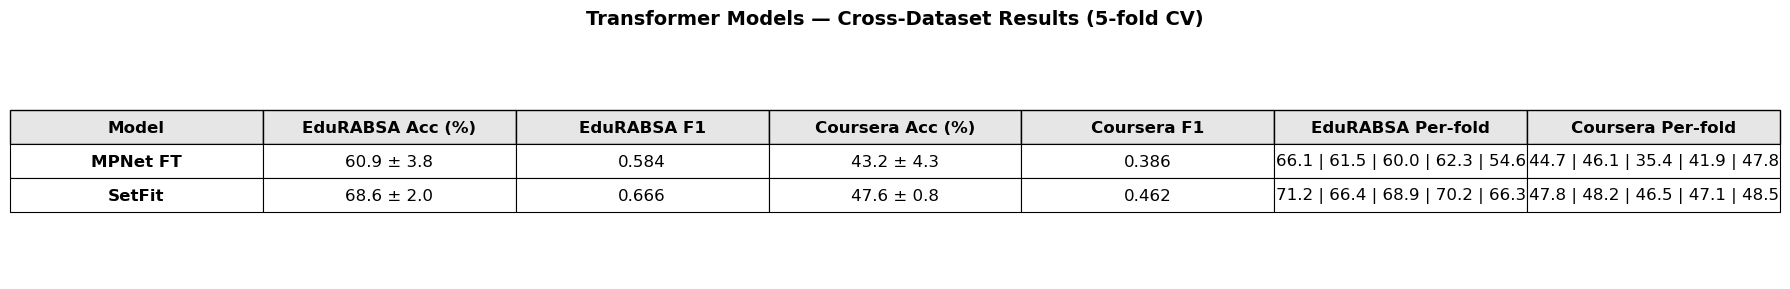

✅ Table saved → output/results_table_transformer_clean.png


In [18]:
import matplotlib.pyplot as plt

all_models = [
    ("MPNet FT", results_mpnet, "Transformer"),
    ("SetFit", results_setfit, "Transformer")
]

rows = []
for mname, rdict, group in all_models:
    edu = rdict.get("EduRABSA", {})
    cou = rdict.get("Coursera", {})

    def fmt_acc(r):
        m, s = r.get("accuracy_mean", 0) * 100, r.get("accuracy_std", 0) * 100
        return f"{m:.1f} ± {s:.1f}"

    def fmt_f1(r):
        return f"{r.get('f1_mean', 0):.3f}"

    def fmt_folds(r):
        folds = r.get("per_fold_acc", [])
        return " | ".join([f"{v*100:.1f}" for v in folds]) if folds else "—"

    rows.append([
        mname,
        fmt_acc(edu), fmt_f1(edu),
        fmt_acc(cou), fmt_f1(cou),
        fmt_folds(edu), fmt_folds(cou)
    ])

col_labels = [
    "Model",
    "EduRABSA Acc (%)", "EduRABSA F1",
    "Coursera Acc (%)", "Coursera F1",
    "EduRABSA Per-fold", "Coursera Per-fold"
]

fig, ax = plt.subplots(figsize=(18, 3))
ax.axis("off")

table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
    colLoc="center"
)

# ===== STYLE =====
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.0)

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)

    if r == 0:
        cell.set_facecolor("#E6E6E6")
        cell.set_text_props(weight="bold")
        cell.set_linewidth(1.0)
    else:
        cell.set_facecolor("white")
        if c == 0:
            cell.set_text_props(weight="bold")

# Title
plt.title(
    "Transformer Models — Cross-Dataset Results (5-fold CV)",
    fontsize=14,
    fontweight="bold",
    pad=14
)

plt.tight_layout()

out_png = f"{CFG['output_dir']}/results_table_transformer_clean.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"✅ Table saved → {out_png}")